## Loading individual methods' files needed for Axis 1 and Axis 2

In [36]:
import numpy as np
import pandas as pd

In [37]:
# Chen - TF-IDF

tfidf_dist = np.load('files_required/tfidf_centroid_distances.npy')
tfidf_silhouette_scores = float(np.load('files_required/tfidf_silhouette.npy')[0])
df_classifier = pd.read_csv('files_required/classifier_top_words.csv')
print("TF-IDF's centroid distances :",tfidf_dist)
print("TF-IDF's silhouette scores :",round(tfidf_silhouette_scores,4))
print(df_classifier.head())

TF-IDF's centroid distances : [0.259486 0.288921]
TF-IDF's silhouette scores : 0.0015
                   word  coefficient     period direction
0  planning competition     2.004924  2007-2011  positive
1          web services     1.749023  2007-2011  positive
2    language resources     1.723907  2007-2011  positive
3    global constraints     1.633852  2007-2011  positive
4      article presents     1.569723  2007-2011  positive


In [38]:
# Nithya - Sbert

sbert_minilm_dist = np.load('files_required/sbert_minilm_centroid_distances_nithya.npy')
sbert_specter_dist = np.load('files_required/sbert_specter_centroid_distances_nithya.npy')
sbert_mpnet_dist = np.load('files_required/sbert_mpnet_centroid_distances_nithya.npy')
df_sbert_silhouette = pd.read_csv('files_required/sbert_silhouette_scores_nithya.csv')
df_sbert_pca = pd.read_csv('files_required/sbert_pca_coords_nithya.csv')
df_framing = pd.read_csv('files_required/sbert_framing_heatmap_nithya.csv',index_col=0)
print('MiniLM distances :',sbert_minilm_dist)
print('SPECTER distances :',sbert_specter_dist)
print('MPNet distances :',sbert_mpnet_dist)
print("Sbert's silhouette scores :")
print(df_sbert_silhouette)
print("Sbert's framing heatmap :")
print(df_framing)

MiniLM distances : [0.0461 0.1221]
SPECTER distances : [0.0055 0.0298]
MPNet distances : [0.05   0.1388]
Sbert's silhouette scores :
     MiniLM     MPNet   Specter
0  0.054125  0.055926  0.017233
Sbert's framing heatmap :
                  2007-2011  2012-2016  2017-2021
state-of-the-art   0.645184   0.653826   0.652376
theoretical        0.716743   0.710527   0.646154
real-world appln   0.704933   0.709778   0.679408
new dataset        0.727063   0.736836   0.724791
scaling up         0.715246   0.720552   0.681753
interpretability   0.651922   0.665724   0.657090


In [39]:
# Rohan - PCA

df_pca_tfidf = pd.read_csv('files_required/pca_tfidf_coordinates.csv')
df_pca_minilm = pd.read_csv('files_required/pca_sbert_minilm_coordinates.csv')
df_pca_specter = pd.read_csv('files_required/pca_sbert_specter_coordinates.csv')
df_pca_mpnet = pd.read_csv('files_required/pca_sbert_mpnet_coordinates.csv')
print("TF-IDF's PCA shape : ",df_pca_tfidf.shape)
print("Specter's PCA shape : ",df_pca_specter.shape)

TF-IDF's PCA shape :  (27121, 5)
Specter's PCA shape :  (27121, 5)


In [40]:
# Shu - Topic Modeling(LDA)

period_topics_lda = pd.read_csv('files_required/lda_period_topics.csv',index_col=0)
js_distances_lda = np.load('files_required/lda_js_distances.npy')
topic_words_lda = pd.read_csv('files_required/lda_topic_words.csv')
print('LDA Period-Topic matrix:')
print(period_topics_lda)
print("LDA's JS distances :",js_distances_lda)

LDA Period-Topic matrix:
                  0         1         2         3         4         5  \
period                                                                  
2007-2011  0.009464  0.084385  0.031546  0.179022  0.307571  0.027603   
2012-2016  0.026344  0.072357  0.047636  0.117827  0.211115  0.036629   
2017-2021  0.089311  0.049333  0.106346  0.106740  0.075723  0.063709   

                  6         7         8         9        10        11  
period                                                                 
2007-2011  0.018139  0.022082  0.009464  0.043375  0.237382  0.029968  
2012-2016  0.019848  0.041140  0.046012  0.077228  0.265789  0.038073  
2017-2021  0.075624  0.062134  0.104328  0.156418  0.037270  0.073064  
LDA's JS distances : [0.149044 0.329029]


In [41]:
# Clarence - Textrank

df_textrank = pd.read_csv('files_required/textrank_per_period.csv')
df_textrank = df_textrank.rename(columns={'period' : 'year_bin','keyword' : 'keyphrases','score': 'count'}) # to standardise column names
print(df_textrank.head())
print('\nTextrank Data - Periods :',df_textrank['year_bin'].unique())

                    keyphrases  count   year_bin
0       support vector machine     14  2007-2011
1  natural language processing     12  2007-2011
2             machine learning     11  2007-2011
3      artificial intelligence     10  2007-2011
4               neural network      8  2007-2011

Textrank Data - Periods : <ArrowStringArray>
['2007-2011', '2012-2016', '2017-2021']
Length: 3, dtype: str


## Axis 1

### Centroid Distance Table (TF-IDF,SBERT,LDA)

In [42]:
import matplotlib.pyplot as plt

In [ ]:
YEARS_RANGE = ['2007-2011','2012-2016','2017-2021'] # standardising it for the rest of the code
TRANSITION_YEARS = ['2007-2011 to 2012-2016','2012-2016 to 2017-2021']

In [59]:
dist_results = {}   
dist_results['TF-IDF'] = list(tfidf_dist)
dist_results['SBERT - MiniLM'] = list(sbert_minilm_dist)
dist_results['SBERT - Specter'] = list(sbert_specter_dist)
dist_results['SBERT - MPNet'] = list(sbert_mpnet_dist)
dist_results['LDA'] = list(js_distances_lda)

df_comparison = pd.DataFrame(dist_results,index=TRANSITION_YEARS).T     # to make the methods as rows
print('Centroid Distance Table :')
print(df_comparison.to_string())
df_comparison['mean_shift'] = df_comparison.mean(axis=1)
print('\nMean Shift :')
print(df_comparison['mean_shift'].sort_values(ascending=False))
df_comparison = df_comparison.drop(columns='mean_shift')


Centroid Distance Table :
                 2007-2011 to 2012-2016  2012-2016 to 2017-2021
TF-IDF                         0.259486                0.288921
SBERT - MiniLM                 0.046100                0.122100
SBERT - Specter                0.005500                0.029800
SBERT - MPNet                  0.050000                0.138800
LDA                            0.149044                0.329029

Mean Shift :
TF-IDF             0.274203
LDA                0.239037
SBERT - MPNet      0.094400
SBERT - MiniLM     0.084100
SBERT - Specter    0.017650
Name: mean_shift, dtype: float64


### Grouped Bar Chart

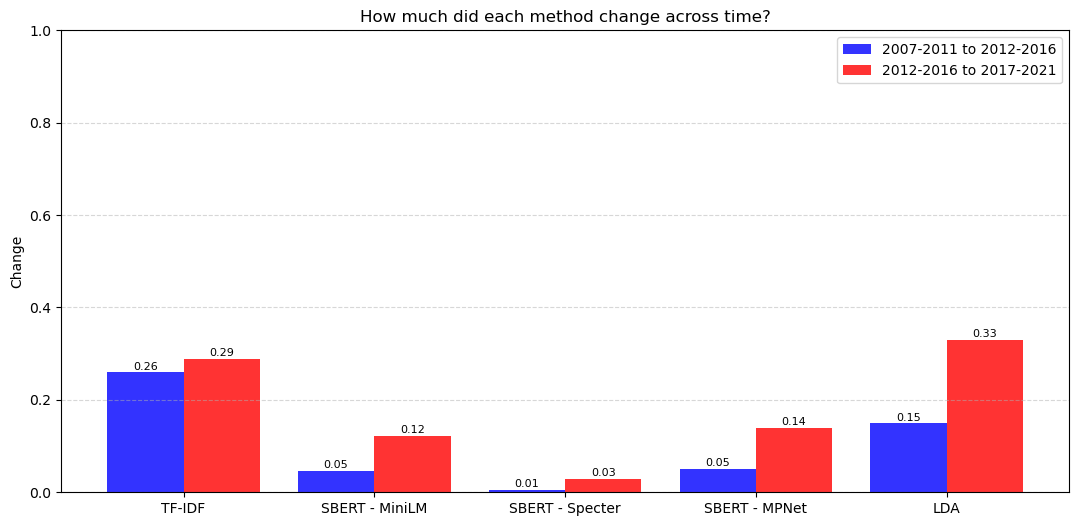

In [62]:
methods = list(df_comparison.index)
x = np.arange(len(methods))
width = 0.4

fig,ax = plt.subplots(figsize=(13,6))
bar_blue = ax.bar(x-width/2,df_comparison[TRANSITION_YEARS[0]],width,label=TRANSITION_YEARS[0],color='blue',alpha=0.8)
bar_red = ax.bar(x+width/2,df_comparison[TRANSITION_YEARS[1]],width,label=TRANSITION_YEARS[1],color='red',alpha=0.8)

# adding the exact values on top 
for bar in bar_blue:
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.002,f'{bar.get_height():.2f}',ha='center',va='bottom',fontsize=8)
for bar in bar_red:
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.002,f'{bar.get_height():.2f}',ha='center',va='bottom',fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel('Change')
ax.set_title('How much did each method change across time?')
ax.legend()
ax.set_ylim(0,1)
ax.grid(axis='y',linestyle='--',alpha=0.5)
plt.savefig('final_figures/axis1_grouped_bar_chart.png',dpi=150)
plt.show()